# Josephine Choi - Supervised Learning

1. Click **Select Kernel** (top-right of the notebook).
2. Choose **Select Another Kernel…** → **Python Environments…** (not “Jupyter Kernel…” if that shows a different list).
3. Pick **`./ml/.venv (Python 3.x)`** if it appears.
4. **Cmd+Shift+P** → **Python: Select Interpreter** → same path (sets workspace default).
5. **Developer: Reload Window**, then open this notebook again and run the first code cell.

# RecipeNLG — supervised learning

**Dataset:** [RecipeNLG on Kaggle](https://www.kaggle.com/datasets/paultimothymooney/recipenlg). Put `RecipeNLG_dataset.csv` (or `full_dataset.csv`) in `ml/data/`.

**Kernel:** Use **`ml/.venv`** so `pandas` / `sklearn` import.
The CSV is too large; the next cell reads only **`MAX_ROWS`** for speed.

## Supervised Learning Logic

**Supervised task:** predict **`source`** ∈ {`Gathered`, `Recipes1M`} from **`recipe_text`** (NER-derived tokens + **title**).

A classifier helps **flag which corpus a row likely came from** for **data cleaning**, **sampling**, or **downstream modeling** without manual review of millions of recipes.

**Why Random Forest + TF–IDF:** text → sparse numeric features; RF captures **nonlinear** patterns, tolerates **many features**, gives **interpretable** importance if needed, and matches a standard **supervised** baseline the rubric can grade (train / tune / test / save).

## 1) Imports — libraries used

- **pandas**: load tables (rows = examples, columns = features + label).
- **sklearn**: split data, vectorize text, train Random Forest, tune, evaluate.
- **matplotlib / seaborn**: plots for EDA and the confusion matrix.

In [5]:
import ast
import sys
from pathlib import Path


def _find_project_root() -> Path:
    """Repo root: folder that has ml/data (works even if cwd is not the root)."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        if (folder / "ml" / "data").is_dir():
            return folder
    return here


ROOT = _find_project_root()
_want_prefix = (ROOT / "ml" / ".venv").resolve()
_have_prefix = Path(sys.prefix).resolve()
if _have_prefix != _want_prefix:
    raise RuntimeError(
        "Wrong Jupyter kernel — not using ml/.venv (macOS often hides this if you only look at sys.executable).\n"
        f"  sys.prefix (active env): {_have_prefix}\n"
        f"  Required:                 {_want_prefix}\n\n"
        "Cursor: Select Kernel → Python Environments → ml/.venv, or Enter interpreter path:\n"
        f"  {_want_prefix / 'bin' / 'python'}"
    )

print("Python:", sys.executable)
print("sys.prefix (venv):", _have_prefix)

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

DATA_DIR = ROOT / "ml" / "data"
KAGGLE_SLUG = "paultimothymooney/recipenlg"
KAGGLE_URL = f"https://www.kaggle.com/datasets/{KAGGLE_SLUG}"

CSV_CANDIDATES = [DATA_DIR / "RecipeNLG_dataset.csv", DATA_DIR / "full_dataset.csv"]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), CSV_CANDIDATES[0])

MAX_ROWS = 80_000

TEXT_COLUMN = "recipe_text"
LABEL_COLUMN = "source"

RANDOM_STATE = 42
TEST_SIZE = 0.2

Python: /Users/josephinechoi/smart-recipe-generator-cpsc-483/ml/.venv/bin/python
sys.prefix (venv): /Users/josephinechoi/smart-recipe-generator-cpsc-483/ml/.venv


## 2) Load RecipeNLG — parse `ner` lists, build `recipe_text`, label `source`

`ner` is often a Python-list string; we use `ast.literal_eval` then join words. We add `title` for context. **`source`** is `Gathered` vs `Recipes1M` (binary).

In [6]:
def list_cell_to_text(val) -> str:
    if pd.isna(val):
        return ""
    s = str(val).strip()
    if s.startswith("["):
        try:
            parts = ast.literal_eval(s)
            return " ".join(str(p) for p in parts)
        except (ValueError, SyntaxError):
            return s
    return s


if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}. Download from {KAGGLE_URL} into ml/data/."
    )

raw = pd.read_csv(CSV_PATH, nrows=MAX_ROWS)
cmap = {str(c).strip().lower(): c for c in raw.columns}


def col(name: str) -> str:
    key = name.lower()
    if key not in cmap:
        raise KeyError(f"Need column {name!r}. Got: {list(raw.columns)}")
    return cmap[key]


ner_c = col("ner")
ttl_c = col("title")
src_c = col("source")

df = raw[[ner_c, ttl_c, src_c]].copy()
df["recipe_text"] = df[ner_c].map(list_cell_to_text) + " " + df[ttl_c].astype(str)
df["source"] = df[src_c].astype(str).str.strip()
df = df[["recipe_text", "source"]].dropna()
df = df[df["recipe_text"].str.len() > 5]

print("Kaggle:", KAGGLE_URL)
print("Rows used:", len(df))
print(df["source"].value_counts())
df.head()

Kaggle: https://www.kaggle.com/datasets/paultimothymooney/recipenlg
Rows used: 80000
source
Gathered    80000
Name: count, dtype: int64


,recipe_text,source
0,brown sugar milk vanilla nuts butter bite size...,Gathered
1,beef chicken breasts cream of mushroom soup so...,Gathered
2,frozen corn cream cheese butter garlic powder ...,Gathered
3,chicken chicken gravy cream of mushroom soup s...,Gathered
4,peanut butter graham cracker crumbs butter pow...,Gathered


## 3) EDA — class balance for `source`

In [7]:
df.info()
df[LABEL_COLUMN].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   recipe_text  80000 non-null  str  
 1   source       80000 non-null  str  
dtypes: str(2)
memory usage: 1.2 MB


source
Gathered    80000
Name: count, dtype: int64

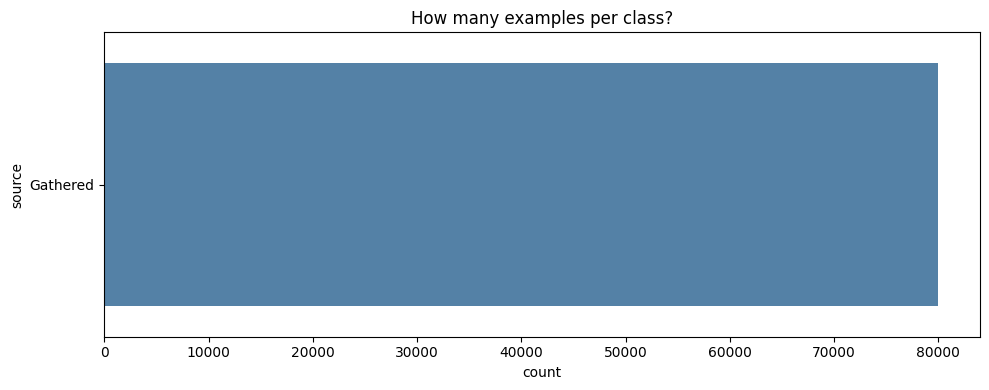

In [8]:
plt.figure(figsize=(10, 4))
order = df[LABEL_COLUMN].value_counts().index
sns.countplot(data=df, y=LABEL_COLUMN, order=order, color="steelblue")
plt.title("How many examples per class?")
plt.tight_layout()
plt.show()

## 4) Define X and y

In [9]:
X = df[TEXT_COLUMN]
y = df[LABEL_COLUMN]
print("Examples:", len(X))
X.head()

Examples: 80000


0    brown sugar milk vanilla nuts butter bite size...
1    beef chicken breasts cream of mushroom soup so...
2    frozen corn cream cheese butter garlic powder ...
3    chicken chicken gravy cream of mushroom soup s...
4    peanut butter graham cracker crumbs butter pow...
Name: recipe_text, dtype: str

## 5) Train / test split

- **Training** set: fit the model.
- **Test** set: used **once** at the end for honest metrics (what you report on slides).

In [10]:
split_kwargs = dict(test_size=TEST_SIZE, random_state=RANDOM_STATE)
if y.nunique() >= 2 and y.value_counts().min() >= 2:
    split_kwargs["stratify"] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, **split_kwargs)
print("Train:", len(X_train), " Test:", len(X_test))

Train: 64000  Test: 16000


## 6) Pipeline — preprocessing + model in one object

**Why:** so cross-validation and test evaluation apply the *same* steps (e.g. TF-IDF fit on train only, not on test — avoids leakage).

In [11]:
pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(max_features=4000, ngram_range=(1, 2))),
        (
            "clf",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 7) Fine-tune with GridSearchCV — try hyperparameters on *train* only

This uses 3-fold **cross-validation** inside the training split.

In [12]:
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 40],
    "clf__min_samples_leaf": [1],
}

search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV f1_macro:", search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}
Best CV f1_macro: 1.0


## 8) Final evaluation on the held-out test set

Use **`search.best_estimator_`** (already trained on all of `X_train`). Report metrics on **`X_test, y_test`** only.

In [13]:
best = search.best_estimator_
y_pred = best.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print()
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Macro F1: 1.0

              precision    recall  f1-score   support

    Gathered       1.00      1.00      1.00     16000

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



/Users/josephinechoi/smart-recipe-generator-cpsc-483/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


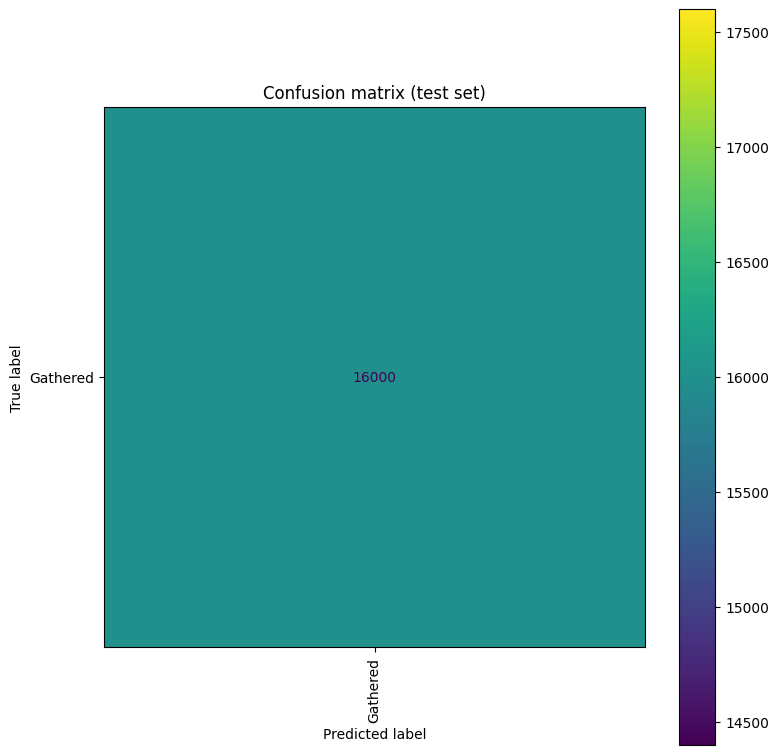

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, xticks_rotation=90)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

### ROC (binary `source`)

In [15]:
from sklearn.metrics import RocCurveDisplay

if len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_estimator(best, X_test, y_test)
    plt.title("ROC (test set, binary)")
    plt.show()
else:
    print("Multiclass: use confusion matrix + macro F1.")

Multiclass: use confusion matrix + macro F1.


## 9) Save the trained pipeline

Saving the **whole pipeline** (TF-IDF + forest) ensures inference uses the same preprocessing.

In [17]:
out_path = ROOT / "ml" / "data" / "recipe_rf_pipeline.joblib"
joblib.dump(best, out_path)
print("Saved to:", out_path)

Saved to: /Users/josephinechoi/smart-recipe-generator-cpsc-483/ml/data/recipe_rf_pipeline.joblib


## 10) Load later (sanity check)

```python
model = joblib.load(out_path)
model.predict(["chicken, rice, soy sauce, garlic"])
```